In [6]:
!pip install matplotlib numpy

In [50]:
import lightning as L
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torch.utils.data import random_split

In [51]:
L.seed_everything(42)

Seed set to 42


42

In [52]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [53]:
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

In [54]:
print("Train size:", len(train_ds))
print("Test size:", len(test_dataset))

image, label = train_dataset[0]
print("Image shape:", image.shape) 
print("Label:", label)

Train size: 54000
Test size: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


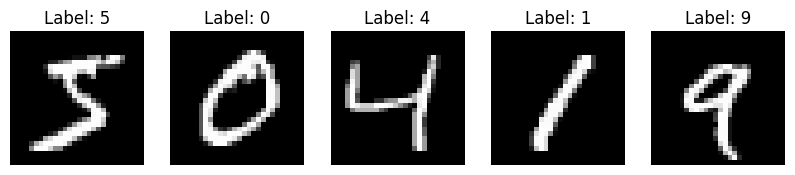

In [55]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.show()

In [56]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [57]:
len(train_ds), len(val_ds), len(test_dataset)

(54000, 6000, 10000)

## Creating a MLP

In [58]:
class MLP(L.LightningModule):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [59]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",   
    patience=3,        
    mode="min"           
)
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    filename="best-mlp",
    save_top_k=1,     
    mode="min"
)

In [60]:
model = MLP()
trainer = L.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback]
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [61]:
trainer.fit(model, train_loader, val_loader)


  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | Sequential | 109 K  | train | 0    
-----------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.438     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 10: 100%|██████████| 844/844 [00:07<00:00, 119.30it/s, v_num=0, val_loss=0.0998, val_acc=0.976]


In [40]:
trainer.test(model, test_loader)

d:\harshit\myvenv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 206.71it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9783999919891357
        test_loss           0.0804845541715622
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.0804845541715622, 'test_acc': 0.9783999919891357}]

## Creating a CNN

In [62]:

class CNN(L.LightningModule):
    def __init__(self):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),  # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),  # → (32,14,14)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2)   # → (64,7,7)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.log("train_loss", loss)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean()
        
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [63]:
model = CNN()
trainer = L.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1,
    callbacks=[early_stop_callback, checkpoint_callback]
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [64]:
trainer.fit(model, train_loader, val_loader)


  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | conv_layers | Sequential | 18.8 K | train | 0    
1 | fc_layers   | Sequential | 402 K  | train | 0    
-----------------------------------------------------------
421 K     Trainable params
0         Non-trainable params
421 K     Total params
1.687     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 7: 100%|██████████| 844/844 [00:23<00:00, 35.84it/s, v_num=1, val_loss=0.0464, val_acc=0.989]


In [65]:
trainer.test(model, test_loader)

Testing DataLoader 0: 100%|██████████| 157/157 [00:01<00:00, 109.42it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc             0.989300012588501
        test_loss          0.035739701241254807
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.035739701241254807, 'test_acc': 0.989300012588501}]